In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:17pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:17pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈 (pandas) </font>
# 9절. 데이터 그룹화 및 집계

In [4]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf. pivot_table

In [10]:
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [12]:
# 1) 그룹화 방법 1
#    df.groupby(=[그룹핑할열이름])[함수적용해서출력할열들].기초통계함수()
    # [함수적용해서출력할열들] 생략시 모든 열이 적용
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum   # iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [15]:
# setosa, virgnica
iris_grouped_sum.loc[['setosa','virginica']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [16]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [18]:
iris_grouped_sum.reset_index(inplace=True) # 인덱스를 컬럼으로 편입시킴

In [19]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [22]:
# setosa, virginica 집계만
iris_grouped_sum[(iris_grouped_sum.Species=='setosa') | (iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa', 'virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [24]:
# 1) 그룹화 방법 1-1 : 그룹핑할때 index를 컬럼 데이터로 편입(reset_index()가 필요 X)
#    df.groupby(=[그룹핑할열이름], as_index=False)[함수적용해서출력할열들].기초통계함수()
    # [함수적용해서출력할열들] 생략시 모든 열이 적용
iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [26]:
# 종별 Sepal.Length 와 Sepal.Width의 평균
iris.groupby('Species').mean()[ ['Sepal.Length','Sepal.Width'] ]
iris.groupby('Species')[ ['Sepal.Length','Sepal.Width'] ].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [30]:
# 종별 Sepal.Length 의 합계
iris.groupby('Species')['Sepal.Length'].sum() # 결과가 데이터프레임 (1차원)

Species
setosa        250.3
versicolor    296.8
virginica     329.4
Name: Sepal.Length, dtype: float64

In [32]:
iris.groupby('Species')[ ['Sepal.Length'] ].sum() # 결과가 데이터 프레임 (2차원)

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [35]:
# 그룹화방법 1
    # df.groupby(by=[그룹핑할열이름들], as_index=T/F).[함수적용해서출력할열듯].함수명()
# 그룹화방법 2
    # df.pivot_table(index='그룹핑할열이름들' ,
    #                values=['함수적용해서출력할열들'],
    #                aggfunc=함수명(기본값:mean))
g = iris.pivot_table(index='Species'
                # values=
                # aggfunc='mean'
                )
g

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


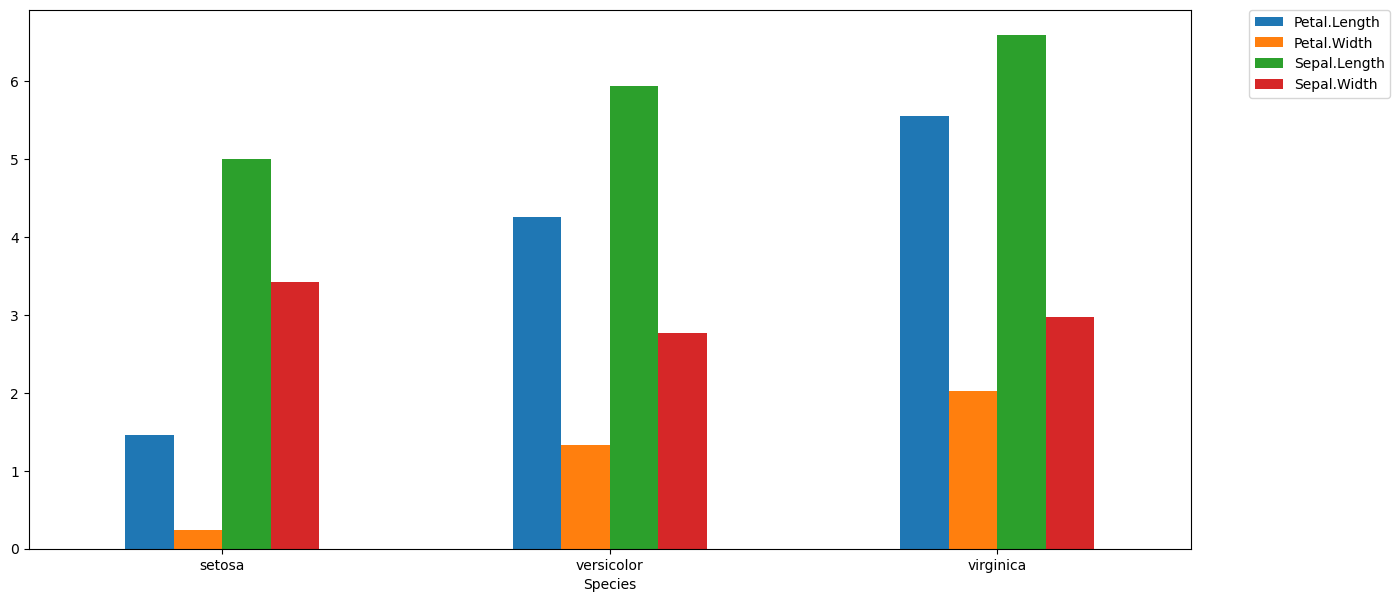

In [53]:
# 범례를 밖으로 : 시각화 20page. 판다스 60page.
import matplotlib.pyplot as plt
g.plot(kind='bar', figsize=(15,7), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [57]:
iris.pivot_table(index='Species',values='Sepal.Length',aggfunc='count')
iris.groupby('Species')[['Sepal.Length']].count()
# iris['Species'].value_count() # 정렬까지

,Sepal.Length
Species,
setosa,50
versicolor,50
virginica,50


In [70]:
# 임의로 각열마다 결측치를 할당(0번째 열은 결측치1 / 1번째열은 결측치2 / 2번째열은 결측치3 / 3번째열은 결측치4)
import numpy as np
import random
# random.sample(range(0,150),2)
for col in range(iris.shape[1]-1):
    rows = (random.sample(range(len(iris)), col+1))
    iris.iloc[rows, col] = np.nan

In [73]:
# 열별 결측치를 제외한 데이터 갯수
iris.groupby('Species').count()
iris.pivot_table(index='Species', aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,49,50,50,48
versicolor,49,49,49,50
virginica,49,47,50,50


### 다중열로 그룹화

In [75]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [80]:
# iris로 다중열 그룹화하기 위해 데이터 추가(num 컬럼)
# iris 행수는 150개 = Species3그룹, num 6그룹
iris['num'] = np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [82]:
# 종별, num별로 합계
r = iris.groupby(['Species','num']).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         82.6          35.4          6.2
           1           124.6         82.1          36.6          6.1
versicolor 2           143.7         69.4         107.8         32.3
           3           146.5         69.1         100.1         32.7
virginica  4           164.4         73.2         135.5         47.3
           5           165.0         75.5         136.6         48.1

In [87]:
r.loc[['setosa', 'virginica']] # setosa와 virginica의 합계만

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         82.6          35.4          6.2
          1           124.6         82.1          36.6          6.1
virginica 4           164.4         73.2         135.5         47.3
          5           165.0         75.5         136.6         48.1

In [88]:
r.loc[[('setosa',0),('virginica',5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,82.6,35.4,6.2
virginica,5,165.0,75.5,136.6,48.1


In [89]:
# 종별, num별로 합계
iris.pivot_table(index=['Species','num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.475000     0.248000        5.0280     3.441667
           1        1.464000     0.244000        4.9840     3.420833
versicolor 2        4.312000     1.345833        5.9875     2.776000
           3        4.170833     1.308000        5.8600     2.764000
virginica  4        5.645833     2.056522        6.5760     2.928000
           5        5.464000     2.004167        6.6000     3.020000

In [91]:
# 종별 기초통계량들 
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   49.000000  50.000000
             mean    5.006000    5.922449   6.588000
             std     0.352490    0.512455   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  48.000000   50.000000  50.000000
             mean    3.431250    2.770000   2.974000
             std     0.320343    0.313798   0.322497
             min     2.900000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.625000    3.000000   3.175000
             max     4.200000    3.400000   3.800000
Petal.Length count  49.000000   49.000000  49.000000
             mean    1.469388    4.242857   5.553061
             std     0.167337    0.458712   0.557562
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.300000   5.600000
             75%     1.600000    4.600000   5.900000
             max     1.900000    5.000000   6.900000
Petal.Width  count  50.000000   49.000000  47.000000
             mean    0.246000    1.326531   2.029787
             std     0.105386    0.199766   0.281236
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000